# 🩺 HealthSense ML v4 — Báo Cáo Tổng Hợp

Notebook này **giải thích toàn bộ pipeline bằng lời** và hiển thị **kết quả thật** đã chạy
(đọc từ `models/`, không huấn luyện lại nên mở ra là chạy được ngay trong vài giây).

**Mục lục:**
1. Bài toán & dữ liệu
2. Đặc trưng HRV — mô hình "nhìn" thấy gì
3. Data leakage & cách đánh giá đúng (LOSO)
4. Kết quả 3 tầng kiểm định
5. Kiểm chứng dò nhịp bằng ECG & giải mã 2 ca đặc biệt
6. Kết luận & giới hạn

> Chi tiết code nằm trong package `src/healthsense_ml/`; chạy lại từ đầu bằng 4 script trong `scripts/`.
> Giải thích mọi thuật ngữ: `docs/index.html` → tab *Giải thích thuật ngữ*.

In [1]:
import sys, json
sys.path.insert(0, '../src')
import pandas as pd
import matplotlib.pyplot as plt
from healthsense_ml import config

pd.set_option('display.float_format', lambda v: f'{v:.4f}')
print('Môi trường sẵn sàng ✔')

Môi trường sẵn sàng ✔


## 1. Bài toán & dữ liệu

**Mục tiêu:** phát hiện **Rung Nhĩ (AFib)** — loạn nhịp tim phổ biến nhất, tăng nguy cơ đột quỵ ~5 lần —
từ tín hiệu **PPG** (đo nhịp tim bằng ánh sáng, chính là cảm biến MAX30102 trên vòng HealthSense).

Dấu hiệu nhận biết AFib: **khoảng cách giữa các nhịp tim trở nên hỗn loạn, không theo quy luật**.
Vì vậy toàn bộ pipeline xoay quanh việc đo "độ hỗn loạn" đó.

Hai bộ dữ liệu công khai được dùng:

| Dataset | Loại tín hiệu | Bệnh nhân | Đặc điểm |
|---|---|---|---|
| MIMIC PERform AF | PPG kẹp ngón 125 Hz | 19 AFib + 16 Normal | Mỗi người 20 phút, có ECG đối chiếu |
| MIT-BIH AFDB | ECG 250 Hz | 25 người | ~10 giờ/người, **AF kịch phát** (lúc bệnh lúc thường) |

Mỗi bản ghi được cắt thành **cửa sổ 30 giây**; mỗi cửa sổ thành 1 hàng dữ liệu
kèm `record_id` — danh tính bệnh nhân, chìa khóa để đánh giá đúng (xem mục 3).

In [2]:
df = pd.read_csv(config.FEATURES_V4_FILE)
print(f'MIMIC: {len(df):,} cửa sổ từ {df.record_id.nunique()} bệnh nhân')
print(df.status.value_counts().rename({0: 'Normal', 1: 'AFib'}).to_string())
df.head(3)

MIMIC: 4,130 cửa sổ từ 35 bệnh nhân
status
AFib      2242
Normal    1888


,record_id,t_start,status,HR_mean,Mean_NN,SDNN,RMSSD,NN50,pNN50,CV,LF,HF,Total_Power,LF_HF_Ratio,LF_norm,HF_norm,SD1,SD2,SampEn
0,mimic_perform_af_001,0.0000,1,89.8938,667.4545,113.7982,175.9070,33,76.7442,0.1705,1380.3628,2706.8381,4728.3404,0.5100,33.7728,66.2272,125.8559,100.3012,1.9459
1,mimic_perform_af_001,10.0000,1,91.3907,656.5217,111.6235,155.0891,30,66.6667,0.1700,842.0663,3894.6632,5222.2671,0.2162,17.7774,82.2226,110.8801,112.3620,2.6391
2,mimic_perform_af_001,20.0000,1,91.3665,656.6957,105.4035,136.0157,26,57.7778,0.1605,991.0239,3989.2570,6031.2882,0.2484,19.8990,80.1010,97.2431,112.9760,2.9444


## 2. Đặc trưng HRV — mô hình "nhìn" thấy gì

Từ mỗi cửa sổ 30s, ta trích **chuỗi NN** (khoảng thời gian giữa 2 nhịp liên tiếp, ms)
rồi tính các con số mô tả nhịp — gọi là đặc trưng **HRV** (Heart Rate Variability):

- **Nhóm thời gian:** `RMSSD`, `pNN50`, `SDNN`… — nhịp càng loạn, số càng lớn.
- **Nhóm phi tuyến:** `SampEn` (độ "khó đoán" của chuỗi nhịp), `SD1/SD2` (hình dáng đồ thị Poincaré).
- **Nhóm tần số:** `HF`, `Total_Power`… (nhóm `LF` bị **loại** vì cửa sổ 30s quá ngắn để đo tin cậy).

Biểu đồ dưới cho thấy vì sao các đặc trưng này phân biệt được AFib — hai phân phối tách nhau rõ:

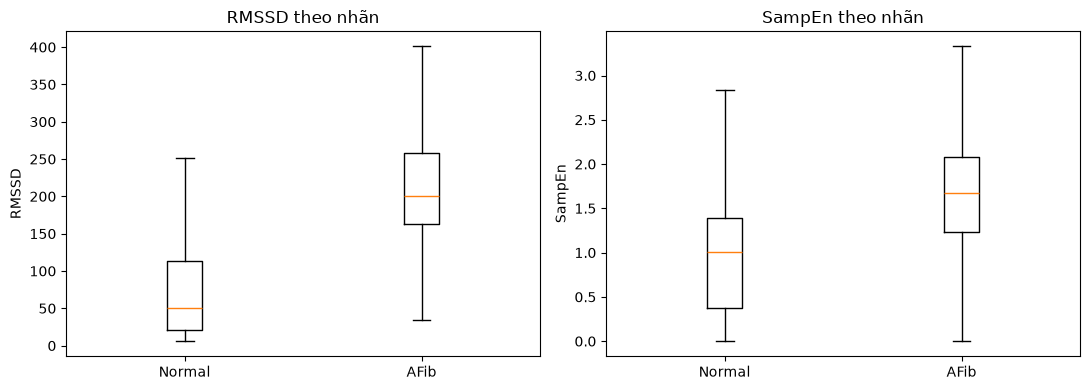

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, feat in zip(axes, ['RMSSD', 'SampEn']):
    data = [df[df.status == 0][feat], df[df.status == 1][feat]]
    ax.boxplot(data, tick_labels=['Normal', 'AFib'], showfliers=False)
    ax.set_title(f'{feat} theo nhãn')
    ax.set_ylabel(feat)
plt.tight_layout(); plt.show()

## 3. Data leakage & cách đánh giá đúng (LOSO)

**Vấn đề của pipeline cũ (v1–v3):** dữ liệu được chia train/test **ngẫu nhiên theo cửa sổ** —
các cửa sổ của *cùng một bệnh nhân* nằm ở cả 2 phía. Mô hình chỉ cần "nhận mặt bệnh nhân"
là đạt 98–99%, giống **học sinh được xem trước đề thi**. Con số đẹp nhưng ảo.

**Cách sửa (v4):** đánh giá bằng **LOSO** (Leave-One-Subject-Out) — có 35 bệnh nhân thì thi 35 vòng,
mỗi vòng **giấu trọn 1 bệnh nhân** làm đề thi, train trên 34 người còn lại. Kèm theo:
- Mọi tiền xử lý (chuẩn hóa, lọc outlier) chỉ được "học" từ phần train của từng vòng.
- Chọn cấu hình mô hình cũng chỉ dùng train (nested GroupKFold).

Điểm số LOSO trả lời đúng câu hỏi thực tế: *"gặp người **mới**, mô hình có nhận ra AFib không?"*

## 4. Kết quả 3 tầng kiểm định

### Tầng 1 — LOSO trên MIMIC (35 bệnh nhân)
Mức **bệnh nhân** = gộp trung bình mọi cửa sổ của một người thành 1 kết luận/người
(con số nên dùng để báo cáo, vì câu hỏi là "người này có bệnh không?"):

In [4]:
bench = pd.read_csv(f'{config.BENCHMARK_V4_DIR}/benchmark_results_v4.csv')
bench[bench.Level == 'subject'][['Model', 'Accuracy', 'Recall (Sensitivity)',
                                 'Specificity', 'F1-Score', 'ROC-AUC', 'FN', 'FP']]

,Model,Accuracy,Recall (Sensitivity),Specificity,F1-Score,ROC-AUC,FN,FP
1,Logistic Regression,0.9429,1.0000,0.8750,0.9500,0.8750,0,2
3,Random Forest,0.9429,1.0000,0.8750,0.9500,0.9309,0,2
5,XGBoost,0.9429,1.0000,0.8750,0.9500,0.9013,0,2


**Đọc kết quả:** `Recall = 1.0` nghĩa là **bắt đủ cả 19 bệnh nhân AFib, không sót ai** (FN = 0).
2 ca báo nhầm (FP) là cùng 2 bệnh nhân "Normal" đặc biệt — được giải mã ở mục 5.

### Tầng 2 — Cross-dataset: bài thi khắc nghiệt nhất
Train trên dataset này, test **toàn bộ** dataset kia — khác bệnh viện, khác loại cảm biến (PPG vs ECG),
khác quần thể. Mô hình giữ được điểm = bằng chứng nó học "dấu hiệu bệnh" chứ không học vẹt:

In [5]:
cross = pd.read_csv(f'{config.MODELS_DIR}/cross_dataset/cross_dataset_results.csv')
cross[['Direction', 'Model', 'Accuracy', 'Recall (Sensitivity)', 'Specificity', 'ROC-AUC']]

,Direction,Model,Accuracy,Recall (Sensitivity),Specificity,ROC-AUC
0,MIMIC -> AFDB,Logistic Regression,0.9384,0.9651,0.9215,0.9721
1,MIMIC -> AFDB,Random Forest,0.9383,0.9563,0.9269,0.9846
2,MIMIC -> AFDB,XGBoost,0.9456,0.9699,0.9303,0.9870
3,AFDB -> MIMIC,Logistic Regression,0.9123,0.9701,0.8438,0.8761
4,AFDB -> MIMIC,Random Forest,0.9186,0.9737,0.8533,0.9757
5,AFDB -> MIMIC,XGBoost,0.9145,0.9755,0.8422,0.9685


AUC giữ ~**0.97–0.99 theo cả 2 chiều** — mức tổng quát hóa rất mạnh.

### Tầng 3 — Model triển khai: gộp 60 bệnh nhân
Gộp cả 2 dataset (cân bằng nguồn bằng sample weight để AFDB 29k cửa sổ không "đè" MIMIC 4k),
đánh giá pooled LOSO 60 vòng, rồi train model cuối trên toàn bộ và xuất `.pkl`:

In [6]:
pooled = pd.read_csv(f'{config.MODELS_DIR}/final/pooled_loso_results.csv')
display(pooled[(pooled.Level == 'window') & (pooled.Subset == 'pooled')]
        [['Model', 'Accuracy', 'Recall (Sensitivity)', 'Specificity', 'ROC-AUC']])

card = json.load(open(f'{config.MODELS_DIR}/final/model_card.json', encoding='utf-8'))
print('Model triển khai:', card['model'], '| version', card['version'])
print('File:', 'models/final/healthsense_afib_pipeline.pkl')
print('Giới hạn:', card['limitations'])

,Model,Accuracy,Recall (Sensitivity),Specificity,ROC-AUC
0,Logistic Regression,0.9478,0.9733,0.9304,0.9700
4,Random Forest,0.9525,0.9655,0.9436,0.9876
8,XGBoost,0.9589,0.9716,0.9501,0.9883


Model triển khai: XGBoost | version 4.1.0
File: models/final/healthsense_afib_pipeline.pkl
Giới hạn: Chưa kiểm định trên PPG cổ tay (MAX30102) và dữ liệu ngoài bệnh viện. Không phải thiết bị chẩn đoán y tế.


## 5. Kiểm chứng dò nhịp bằng ECG & giải mã 2 ca đặc biệt

Toàn bộ đặc trưng phụ thuộc việc **dò nhịp trên PPG có chính xác không**. May mắn MIMIC có cột ECG
ghi song song — dùng R-peak trên ECG làm "đáp án chuẩn" chấm điểm bộ dò nhịp PPG:

In [7]:
bv = pd.read_csv(f'{config.MODELS_DIR}/beat_validation/beat_validation.csv')
print('F1 dò nhịp (median):')
print(bv.groupby('label').f1.median().to_string())
print()
suspects = bv[bv.record_id.isin(['mimic_perform_non_af_012', 'mimic_perform_non_af_014'])]
suspects[['record_id', 'label', 'f1', 'hr_mae_bpm', 'ecg_RMSSD', 'ecg_pNN50']]

F1 dò nhịp (median):
label
AFib     0.8548
Normal   0.9908



,record_id,label,f1,hr_mae_bpm,ecg_RMSSD,ecg_pNN50
30,mimic_perform_non_af_012,Normal,0.3550,29.9000,233.4632,40.6504
32,mimic_perform_non_af_014,Normal,0.1957,23.9500,30.6060,1.5365


**Giải mã 2 bệnh nhân "Normal" bị mô hình báo AFib** (nhìn thẳng vào ECG của họ):

- `non_af_012`: RMSSD tính từ **chính ECG** = 233 ms — còn loạn hơn median nhóm AFib (170 ms).
  → Tim người này loạn thật; **nhãn "Normal" của dataset đáng nghi**, mô hình báo có cơ sở.
- `non_af_014`: RMSSD từ ECG chỉ 31 ms (tim hoàn toàn bình thường) nhưng **PPG hỏng nặng**
  (F1 dò nhịp 0.196, sai số HR 24 bpm). → Mô hình "ăn" phải nhịp rác từ tín hiệu xấu.
  Đây là lý do AI-Service bổ sung **SQI** — tín hiệu kém thì từ chối phân loại thay vì đoán bừa.

Ngoài ra, so **kết quả đo PPG vs ECG cùng thời điểm** trên 1.400 cửa sổ: nhịp tim lệch trung bình
chỉ ~3.5 bpm (r = 0.94) — PPG đủ tin cậy để đo HR và sàng lọc AFib; riêng giá trị HRV tuyệt đối
thì PPG "phóng đại" so với ECG (hiện tượng PRV ≠ HRV kinh điển trong y văn).

## 6. Kết luận & giới hạn

**Kết luận:**
- Pipeline v4 sạch leakage, kiểm định 3 tầng; con số bảo vệ được: LOSO 94.3% / Recall 100%,
  cross-dataset AUC 0.976–0.987, pooled 60 bệnh nhân 95.9% / AUC 0.988.
- Model triển khai (`healthsense_afib_pipeline.pkl`) đã tích hợp vào `HealthSense-AI-Service`
  kèm parity test (service tính giống hệt lab) và SQI.

**Giới hạn cần ghi rõ khi báo cáo:**
- Dataset nhỏ (60 bệnh nhân) → khoảng tin cậy rộng; 2 record MIMIC nghi vấn (nhãn/chất lượng).
- Chưa kiểm định trên **PPG cổ tay MAX30102** ngoài đời thực — bước tiếp theo quan trọng nhất.
- Không phải thiết bị chẩn đoán y tế; kết quả chỉ phục vụ sàng lọc/nghiên cứu.